# 01 — Análise Exploratória de Dados (EDA)

Exploração do dataset **Telco Customer Churn**: distribuições, correlações e análise geográfica.


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

from scipy import stats


In [2]:
df_churn = pd.read_csv("../data/Telco_customer_churn.csv")
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [3]:
df_churn = df_churn.drop(columns=['Count','CustomerID','Churn Reason'])

df_churn.head()

,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372
3,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
4,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340


## 2. Análise Exploratória

Função `analisar_dataframe()` executa 6 fases de análise:
1. Visão geral (shape, tipos, estatísticas descritivas)
2. Valores ausentes
3. Distribuições numéricas (histogramas + boxplots)
4. Distribuições categóricas
5. Matriz de correlação
6. Análise do target

In [4]:
import math

def analisar_dataframe(df: pd.DataFrame, col_target: str | None = None, nome_dataset: str = 'Dataset', ignorar_colunas: list[str] | None = None) -> None:
    """
    Realiza uma análise exploratória inicial de um DataFrame.
    
    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame a ser analisado.
    col_target : str, opcional
        Nome da coluna target para análise de distribuição.
    nome_dataset : str
        Nome do dataset para uso nos títulos dos gráficos.
    ignorar_colunas : list, opcional
        Lista de colunas a excluir da análise (ex: IDs, chaves).
    """
    cores_bin = ['#4C72B0', '#DD8452']
    sns.set_style('whitegrid')

    if ignorar_colunas is not None:
        colunas_validas = [c for c in ignorar_colunas if c in df.columns]
        df = df.drop(columns=colunas_validas)
        if colunas_validas:
            print(f"ℹ️  Colunas ignoradas: {colunas_validas}")

    # Tentativa de converter colunas object para numérico
    # Só converte se todos os valores não-nulos contiverem apenas números e espaços (sem letras)
   

    colunas_num = df.select_dtypes(include=[np.number]).columns.tolist()
    colunas_cat = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    # ─────────────────────────────────────────────
    # FASE 1 — Visão Geral
    # ─────────────────────────────────────────────
    print("=" * 60)
    print(f"  ANÁLISE EXPLORATÓRIA — {nome_dataset.upper()}")
    print("=" * 60)

    print(f"\n📐 Shape: {df.shape[0]} linhas × {df.shape[1]} colunas")
    print(f"\n🔢 Colunas numéricas ({len(colunas_num)}): {colunas_num}")
    print(f"🔤 Colunas categóricas ({len(colunas_cat)}): {colunas_cat}")

    print("\n─── Tipos de dados ───")
    print(df.dtypes.to_string())

    print("\n─── Estatísticas descritivas (numéricas) ───")
    print(df.describe().to_string())

    # ─────────────────────────────────────────────
    # FASE 2 — Valores Ausentes
    # ─────────────────────────────────────────────
    print("\n─── Valores ausentes ───")
    missing_count = df.isnull().sum()
    missing_pct = (missing_count / len(df)) * 100
    missing_df = pd.DataFrame({
        'Valores ausentes': missing_count,
        'Porcentagem (%)': missing_pct.round(2)
    }).sort_values('Porcentagem (%)', ascending=False)
    print(missing_df[missing_df['Valores ausentes'] > 0].to_string()
          if missing_df['Valores ausentes'].sum() > 0
          else "Nenhum valor ausente encontrado.")

    ausentes = missing_pct[missing_pct > 0].sort_values(ascending=False)
    if not ausentes.empty:
        fig, ax = plt.subplots(figsize=(10, max(3, len(ausentes) * 0.5 + 1)))
        sns.barplot(x=ausentes.values, y=ausentes.index, ax=ax, palette='Reds_r')
        ax.set_xlabel('% de valores ausentes')
        ax.set_title(f'Valores Ausentes por Coluna — {nome_dataset}', fontweight='bold')
        for i, v in enumerate(ausentes.values):
            ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────
    # FASE 3 — Distribuições Numéricas
    # ─────────────────────────────────────────────
    if colunas_num:
        ncols = 3
        nrows = math.ceil(len(colunas_num) / ncols)

        # Histogramas + KDE
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
        fig.suptitle(f'Distribuições Numéricas — {nome_dataset}', fontsize=14, fontweight='bold')
        axes_flat = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()
        for i, col in enumerate(colunas_num):
            sns.histplot(df[col].dropna(), kde=True, ax=axes_flat[i], color=cores_bin[0])
            axes_flat[i].set_title(col)
            axes_flat[i].set_xlabel('')
        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)
        plt.tight_layout()
        plt.show()

        # Boxplots
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
        fig.suptitle(f'Boxplots — {nome_dataset}', fontsize=14, fontweight='bold')
        axes_flat = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()
        for i, col in enumerate(colunas_num):
            sns.boxplot(y=df[col].dropna(), ax=axes_flat[i], color=cores_bin[0])
            axes_flat[i].set_title(col)
        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────
    # FASE 4 — Distribuições Categóricas
    # ─────────────────────────────────────────────
    if colunas_cat:
        ncols = 3
        nrows = math.ceil(len(colunas_cat) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
        fig.suptitle(f'Distribuições Categóricas — {nome_dataset}', fontsize=14, fontweight='bold')
        axes_flat = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()
        for i, col in enumerate(colunas_cat):
            ordem = df[col].value_counts().index
            sns.countplot(data=df, y=col, order=ordem, ax=axes_flat[i], palette='Blues_d')
            axes_flat[i].set_title(col)
            axes_flat[i].set_xlabel('Contagem')
        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────
    # FASE 5 — Correlação
    # ─────────────────────────────────────────────
    if len(colunas_num) >= 2:
        corr = df[colunas_num].corr()
        fig, ax = plt.subplots(figsize=(max(6, len(colunas_num) * 0.8), max(5, len(colunas_num) * 0.7)))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    linewidths=0.5, ax=ax)
        ax.set_title(f'Correlação entre Variáveis Numéricas — {nome_dataset}', fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────
    # FASE 6 — Análise do Target (opcional)
    # ─────────────────────────────────────────────
    if col_target and col_target in df.columns:
        target = df[col_target]
        n_unique = target.nunique()

        print(f"\n─── Distribuição do target: '{col_target}' ───")
        df_dist = pd.DataFrame({
            "Volume": target.value_counts(),
            "Porcentagem": (target.value_counts(normalize=True) * 100).round(2).astype(str) + '%'
        })
        print(df_dist.to_string())

        # Binarizar se mais de 2 valores únicos
        if n_unique > 2:
            mediana = target.median()
            target_plot = (target > mediana).astype(int)
            label_neg = f'≤ {mediana} (0)'
            label_pos = f'> {mediana} (1+)'
        else:
            target_plot = target
            vals = sorted(target.unique())
            label_neg = str(vals[0])
            label_pos = str(vals[1]) if len(vals) > 1 else str(vals[0])

        bin_counts = target_plot.value_counts().sort_index()
        labels = [label_neg, label_pos] if len(bin_counts) == 2 else [str(k) for k in bin_counts.index]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f"Análise do Target: '{col_target}' — {nome_dataset}", fontsize=14, fontweight='bold')

        # Contagem original
        orig = target.value_counts().sort_index()
        axes[0].bar(orig.index.astype(str), orig.values, color=sns.color_palette('Blues_d', len(orig)))
        axes[0].set_title('Contagem por valor (original)')
        axes[0].set_xlabel(col_target)
        axes[0].set_ylabel('Contagem')
        for idx, v in enumerate(orig.values):
            axes[0].text(idx, v + 0.5, str(v), ha='center', fontweight='bold')

        # Pizza
        axes[1].pie(bin_counts.values, labels=labels, autopct='%1.1f%%',
                    colors=cores_bin[:len(bin_counts)], startangle=90)
        axes[1].set_title('Proporção das Classes')

        # Barras binárias
        axes[2].bar(labels, bin_counts.values, color=cores_bin[:len(bin_counts)])
        axes[2].set_title('Contagem das Classes')
        axes[2].set_ylabel('Contagem')
        for idx, v in enumerate(bin_counts.values):
            axes[2].text(idx, v + 0.5, str(v), ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

    print("\n✅ Análise concluída.")


ℹ️  Colunas ignoradas: ['Churn Label']
  ANÁLISE EXPLORATÓRIA — TELCO CUSTOMER CHURN

📐 Shape: 7043 linhas × 29 colunas

🔢 Colunas numéricas (8): ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
🔤 Colunas categóricas (21): ['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges']

─── Tipos de dados ───
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service   

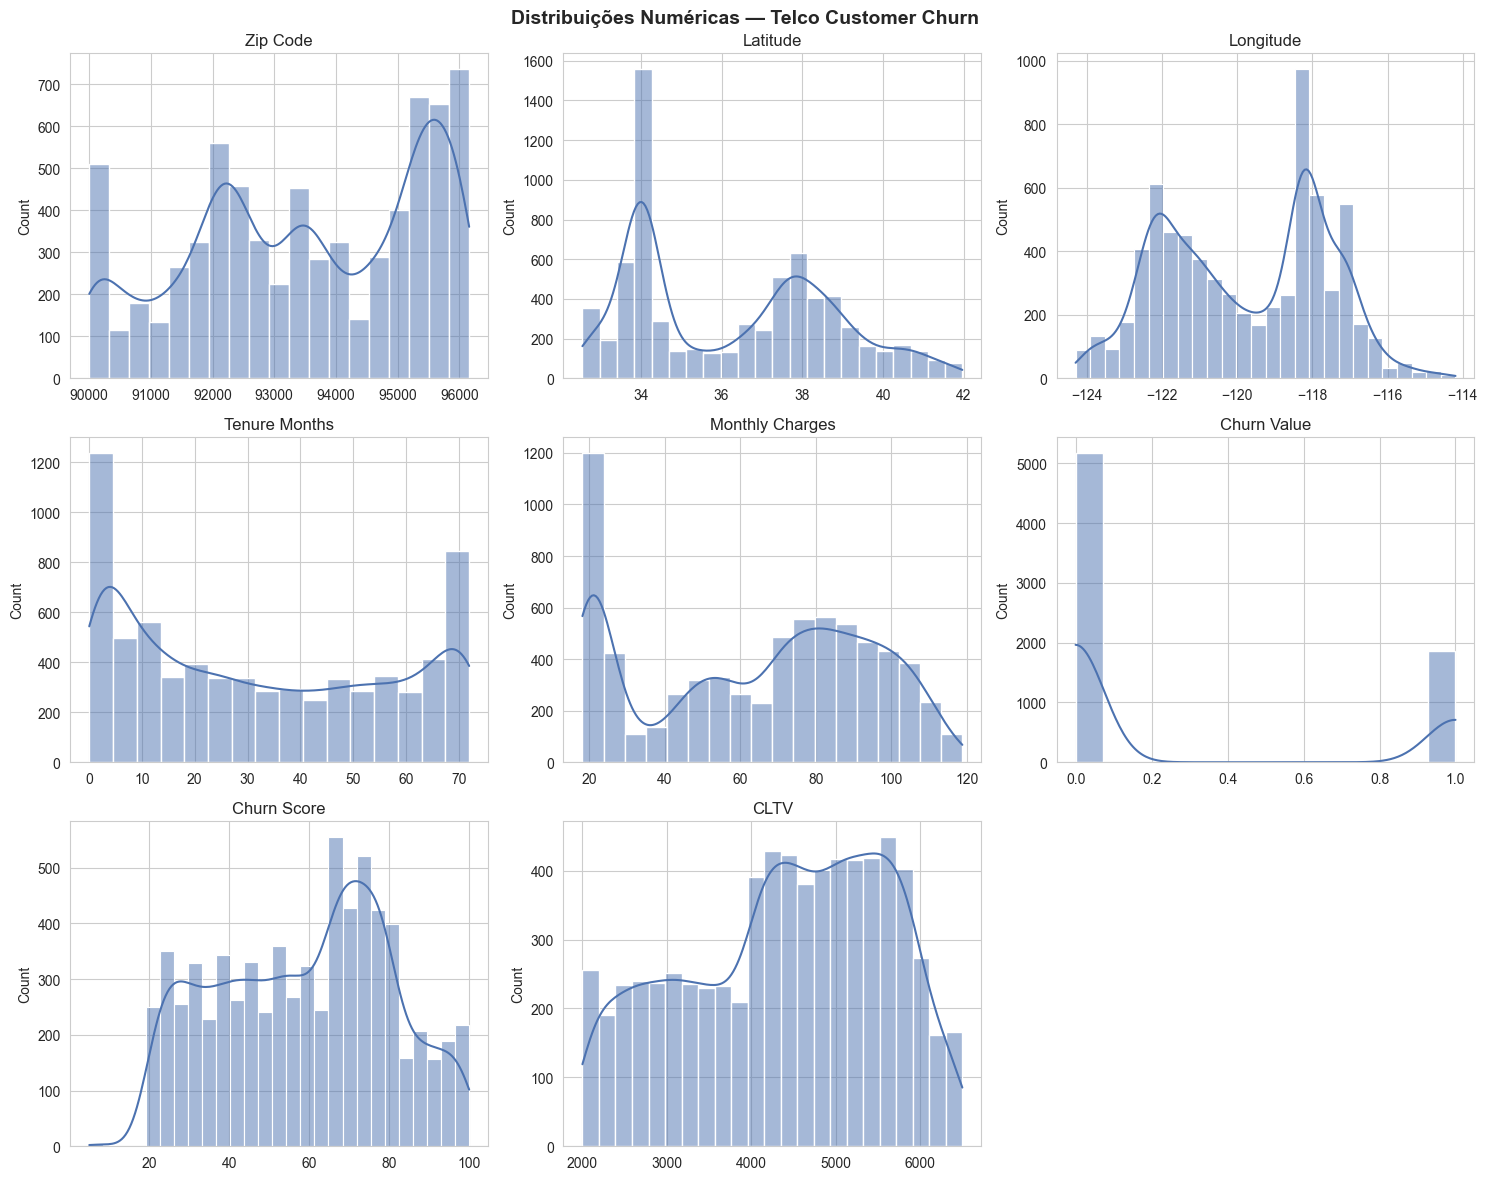

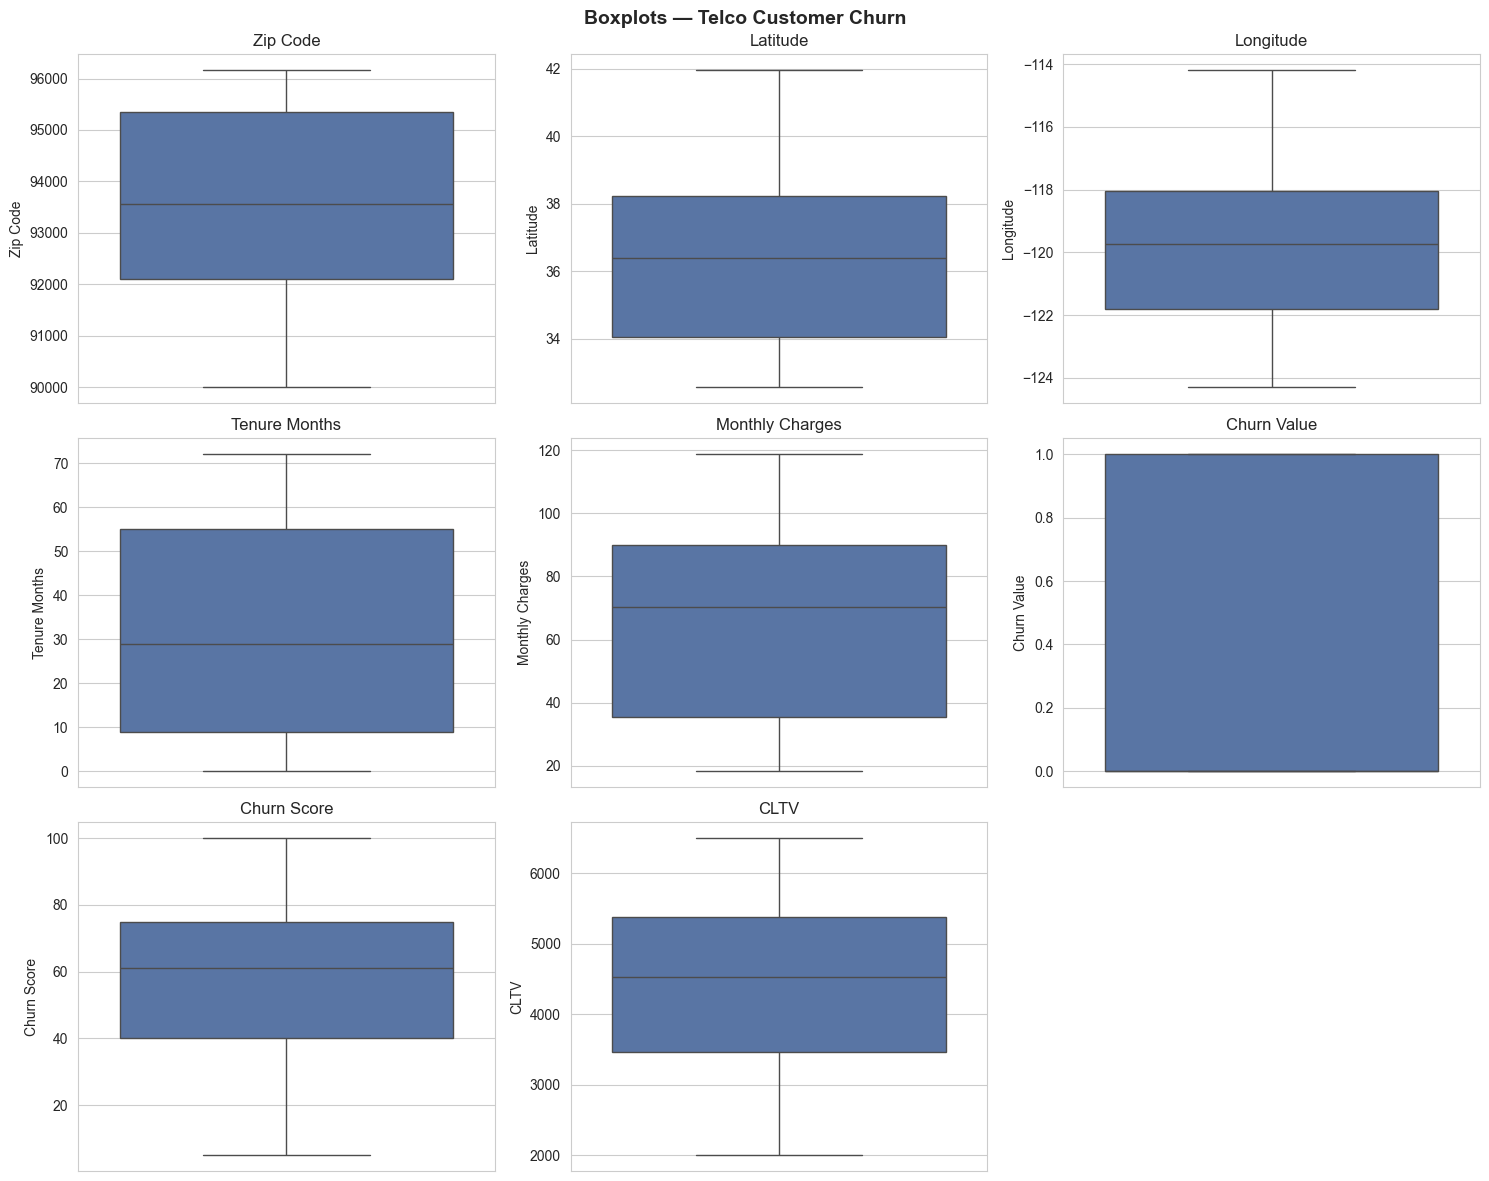

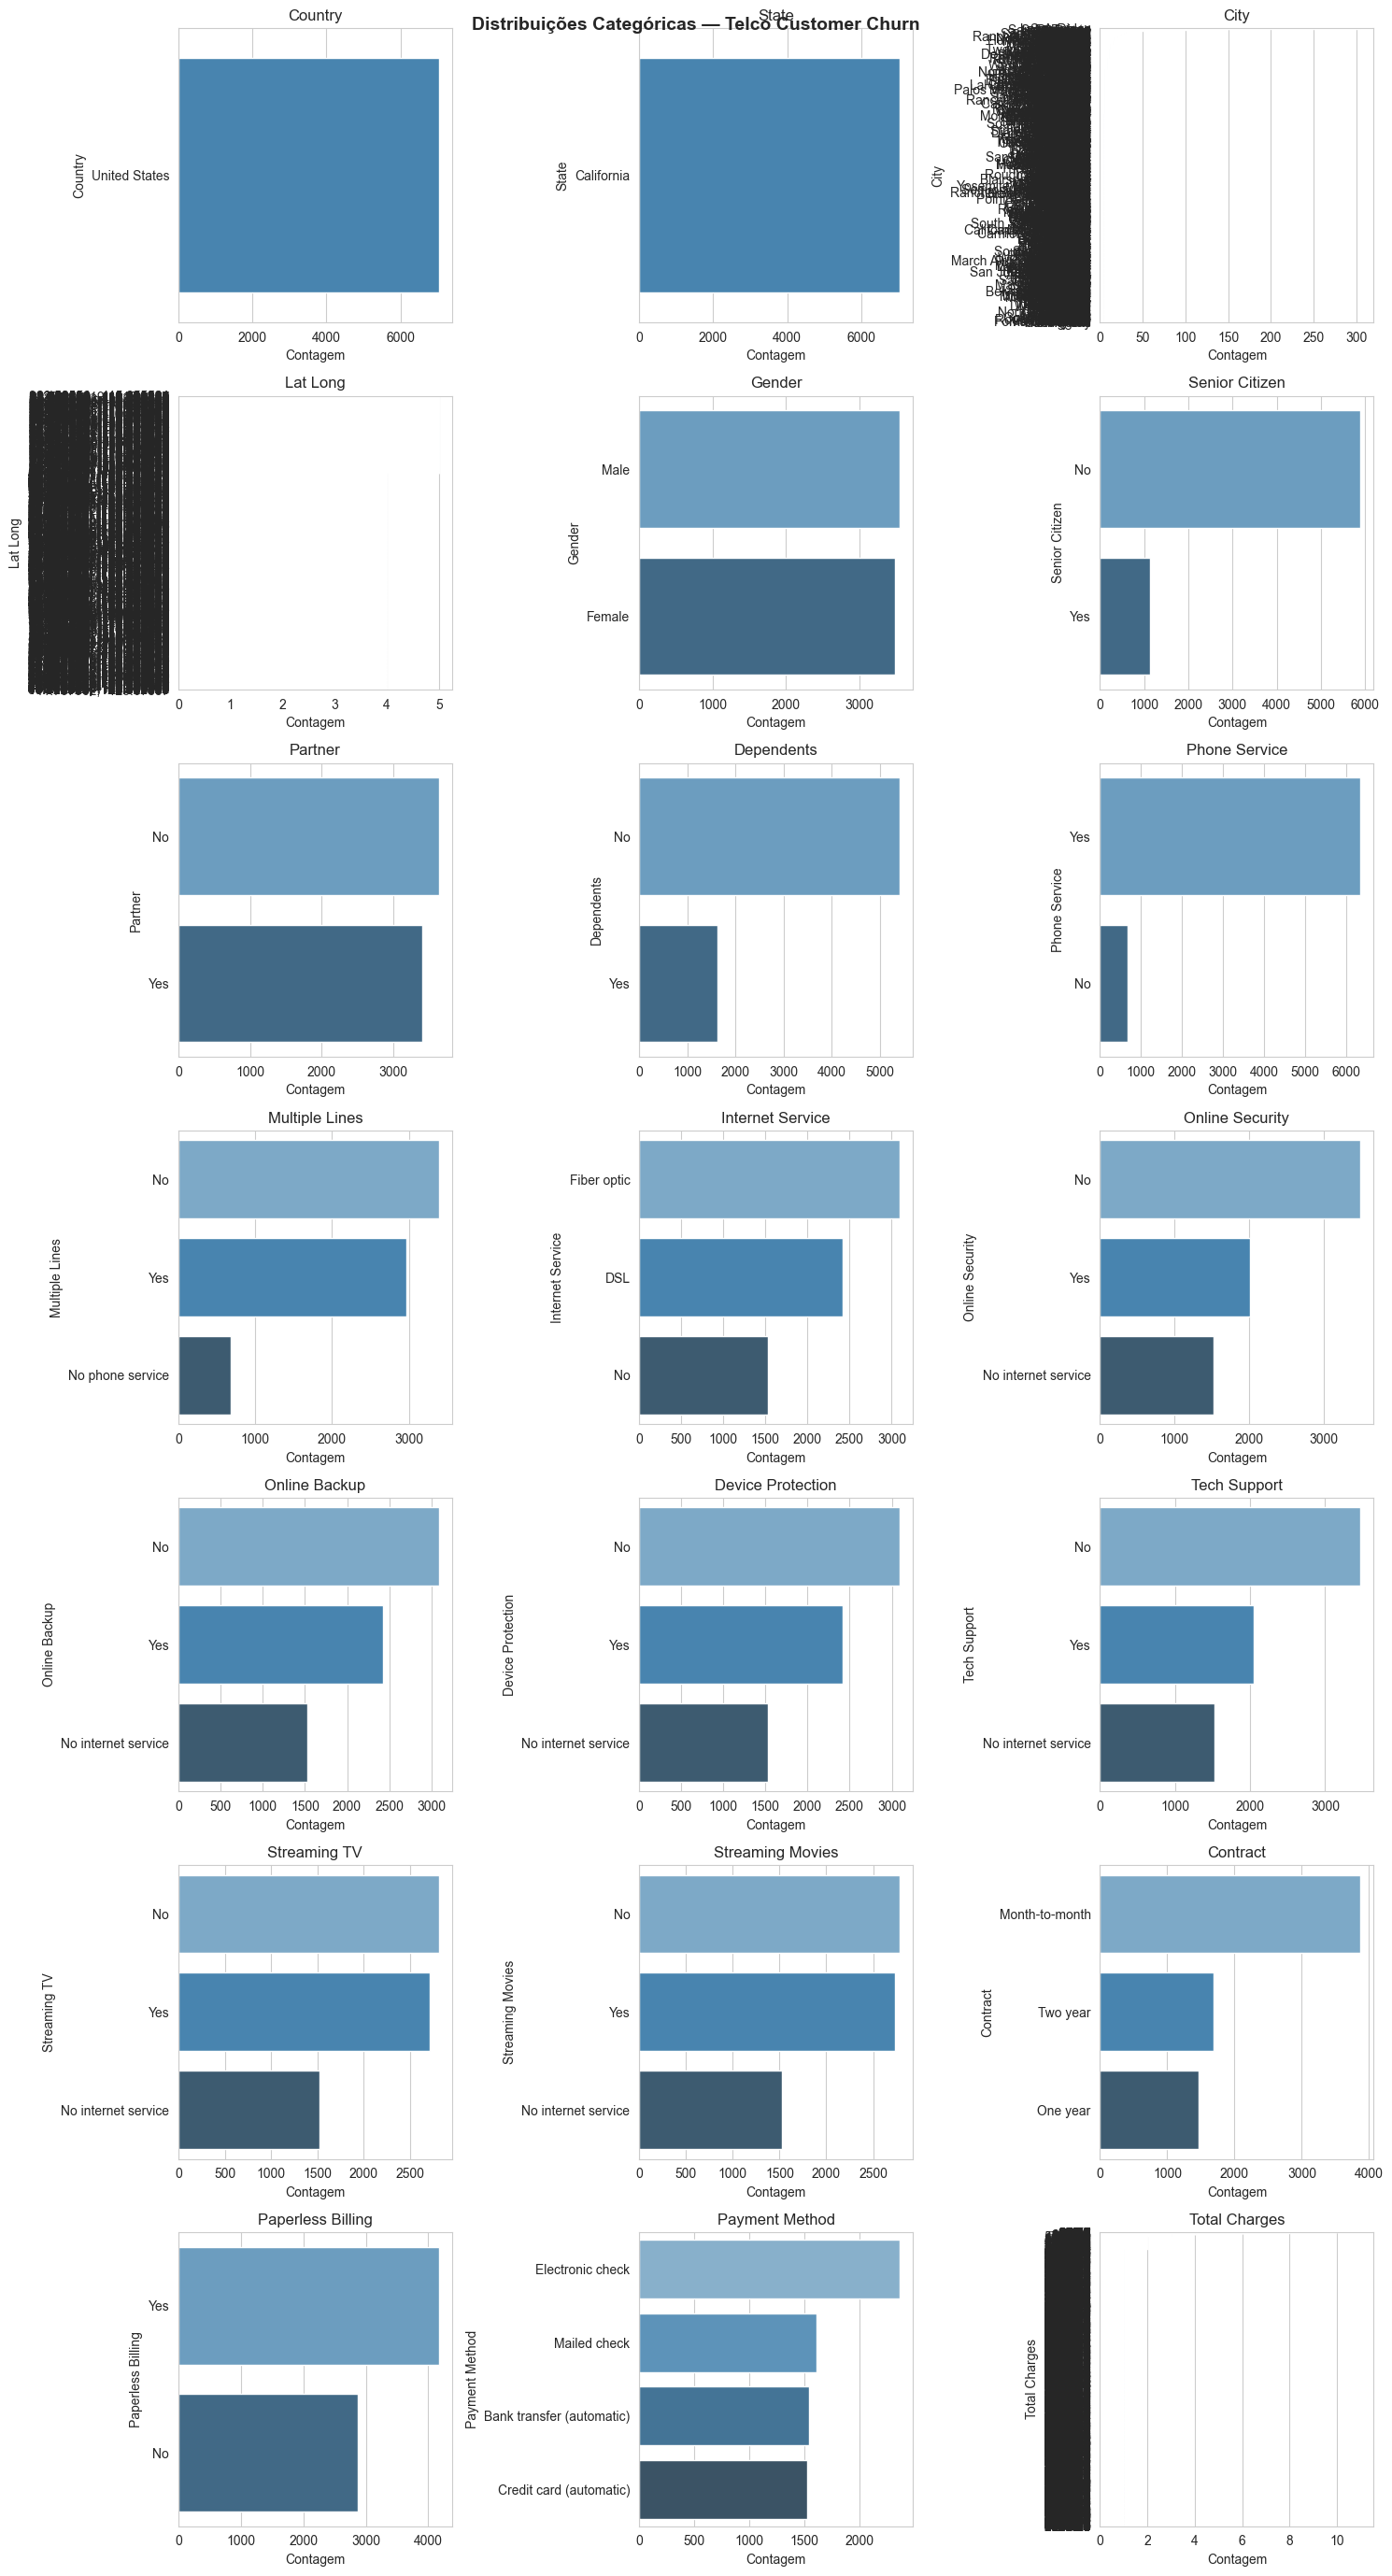

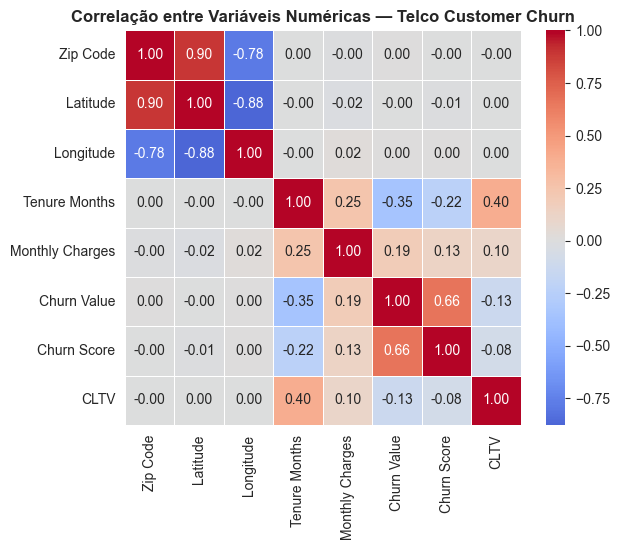


─── Distribuição do target: 'Churn Value' ───
             Volume Porcentagem
Churn Value                    
0              5174      73.46%
1              1869      26.54%


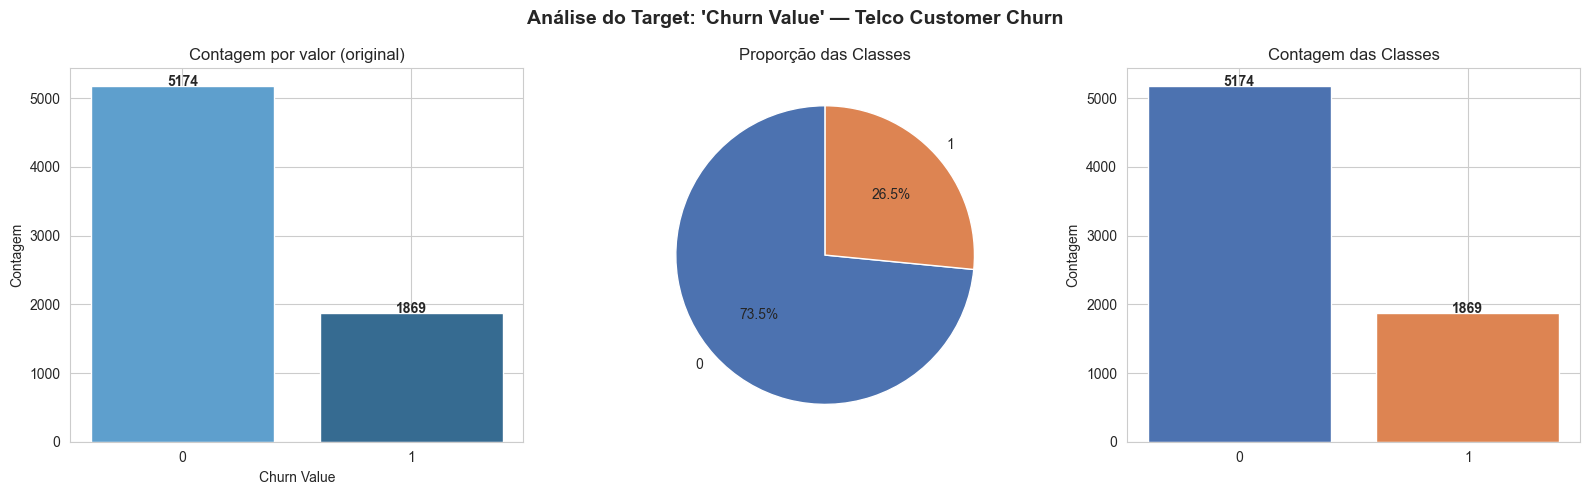


✅ Análise concluída.


In [5]:
#analise do dataframe, a função analisar_dataframe é uma função personalizada que realiza uma análise exploratória inicial de um DataFrame, incluindo informações sobre tipos de dados, estatísticas descritivas, valores ausentes, distribuições num
analisar_dataframe(df_churn, col_target='Churn Value', nome_dataset='Telco Customer Churn', ignorar_colunas=['CustomerID',"Count","Churn Label"])


## 3. Análise Geográfica de Churn

Investigação da distribuição de churn por cidade: taxa de cancelamento, volume de churners e percentual em relação à base local de cada cidade.

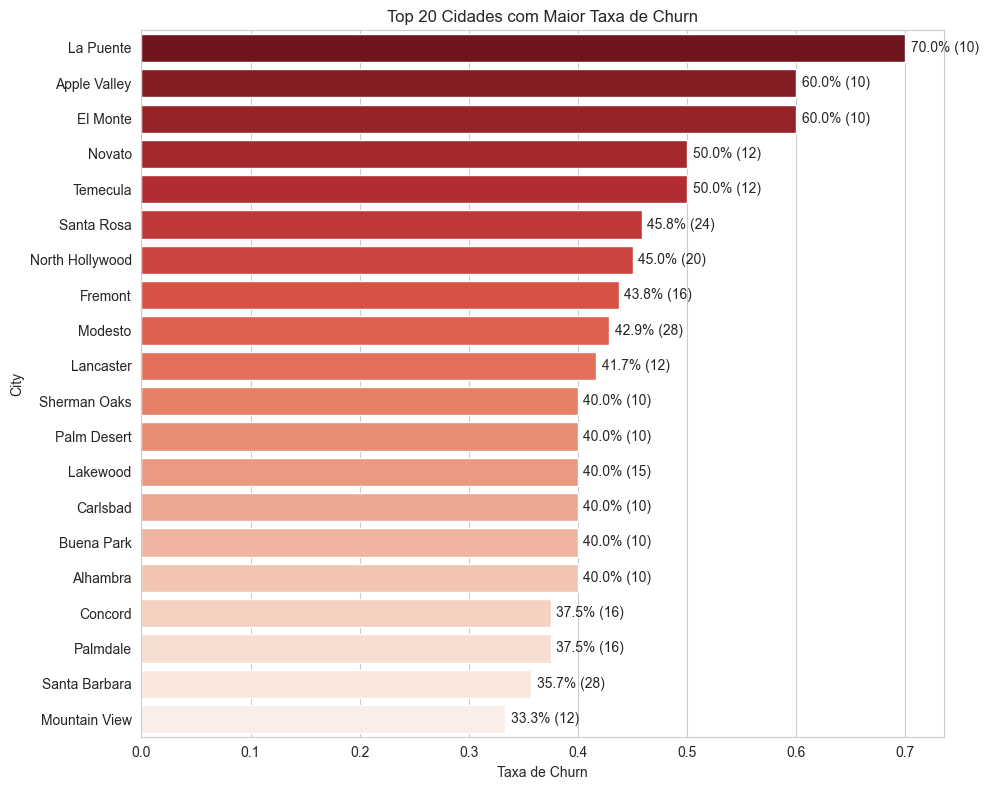

In [6]:
churn_por_cidade = (
    df_churn.groupby('City')['Churn Value']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'taxa_churn', 'count': 'total'})
    .query('total >= 10')          # remove cidades com poucos clientes (ruído)
    .sort_values('taxa_churn', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='taxa_churn', y=churn_por_cidade.index, data=churn_por_cidade,
            palette='Reds_r', ax=ax)
ax.set_xlabel('Taxa de Churn')
ax.set_title('Top 20 Cidades com Maior Taxa de Churn')

# Anotar com total de clientes
for i, (taxa, total) in enumerate(zip(churn_por_cidade['taxa_churn'], churn_por_cidade['total'])):
    ax.text(taxa + 0.005, i, f'{taxa:.1%} ({total})', va='center')

plt.tight_layout()
plt.show()

In [7]:
total_por_cidade = df_churn.groupby('City').size().reset_index(name='total_clientes')

churn_por_cidade = (
    df_churn[df_churn['Churn Value'] == 1]
    .groupby('City')
    .size()
    .reset_index(name='total_churn')
    .merge(total_por_cidade, on='City')
    .assign(pct_churn=lambda x: (x['total_churn'] / x['total_clientes'] * 100).round(2))
    .sort_values('total_clientes', ascending=False)
)
churn_por_cidade

,City,total_churn,total_clientes,pct_churn
417,Los Angeles,90,305,29.51
638,San Diego,50,150,33.33
645,San Jose,29,112,25.89
629,Sacramento,26,108,24.07
641,San Francisco,31,104,29.81
...,...,...,...,...
819,Wofford Heights,1,4,25.00
818,Witter Springs,1,4,25.00
817,Winton,1,4,25.00
816,Winters,2,4,50.00
